In [1]:
%cd "C:\Users\asmaa\Desktop\Amr\Master's Thesis v0.4"

C:\Users\asmaa\Desktop\Amr\Master's Thesis v0.4


C:\Users\asmaa\PycharmProjects\pythonProject\.venv\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import devices
import models
import samplers
import trainers
import utils

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

In [84]:
memory_type = torch.device('cuda')
dtype = torch.float32
num_modes = 1
study = 'TE'

# device 1

In [113]:
# parameters
lambd = 1

# wave number and normalized spacing
k_0 = 2 * np.pi / lambd

# device 1

# spacing
dx = lambd/20 * k_0
dy = lambd/20 * k_0

# simulation lengths
core_length_x = 2 * lambd * k_0 # W
core_length_y = 1 * lambd * k_0 # H

substrate_length_x = 3.0 * lambd * k_0 # Xs
substrate_length_y = 2.0 * lambd * k_0 # Ys

# refractive indices
n_core = 1.55
n_substrate = 1.44

In [114]:
weights = [1/2, 1/2, 8, 1/4, 1, 1]
m = 2

In [115]:
lengths_x = [substrate_length_x, core_length_x, substrate_length_x]
lengths_y = [substrate_length_y, core_length_y, substrate_length_y]
RIs = [n_substrate, n_core]

In [116]:
reference_device = devices.BuriedChannelWaveguide(RIs, lambd, lengths_x, lengths_y, study, 'E')

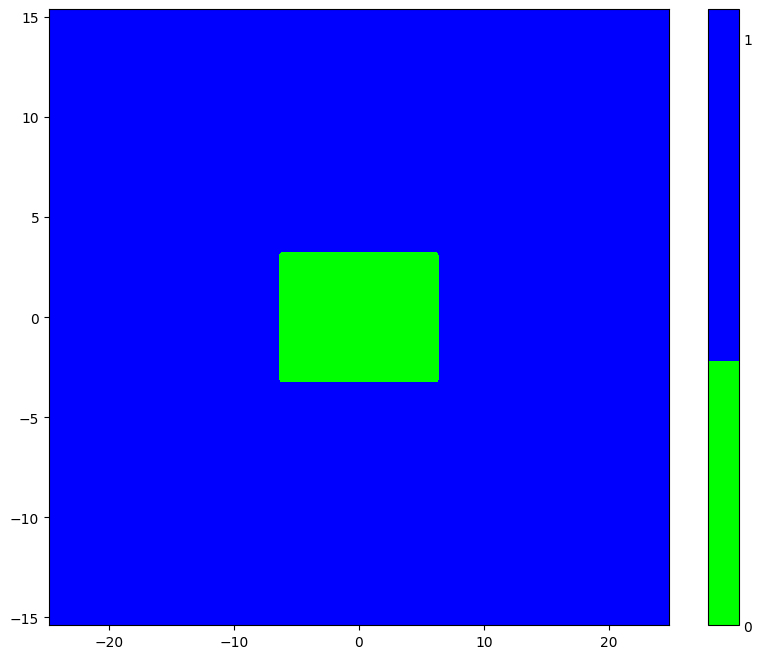

In [117]:
reference_device.plot(dx, dy)

In [118]:
torch.manual_seed(42)
base_model = models.discontinuity_capturing_network(2, 128, num_modes, 2, 'Siren')
optimizer = torch.optim.Adamax(base_model.parameters(), lr=1e-2)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[8000], gamma=1e-1)
print('number of trainable parameters', sum([p.numel() for p in base_model.parameters() if p.requires_grad]))

number of trainable parameters 17153


In [119]:
# mesh = samplers.uniform_grid_2d(reference_device, dx/2, dy/2, dtype, 'cpu')
# features = reference_device.make_features(mesh)
# 
# plt.scatter(mesh[:, 0].cpu().detach(), mesh[:, 1].cpu().detach(), s=1, c=features, cmap='jet');

In [120]:
device = devices.BuriedChannelWaveguideWithPINNs(RIs, lambd, lengths_x, lengths_y, study, 'E', base_model, 1, True)

In [121]:
reference_device_fd = devices.BuriedChannelWaveguideWithFD(RIs, lambd, lengths_x, lengths_y, study, 'E', dx, dy)

In [122]:
train_agent = trainers.Trainer2D(dtype, device, reference_device_fd, memory_type, samplers.uniform_grid_2d, optimizer, scheduler, dx=dx, dy=dy, num_samples=None, n_lower=None, n_upper=None)

  0%|          | 0/10001 [00:00<?, ?it/s]

num samples 15741


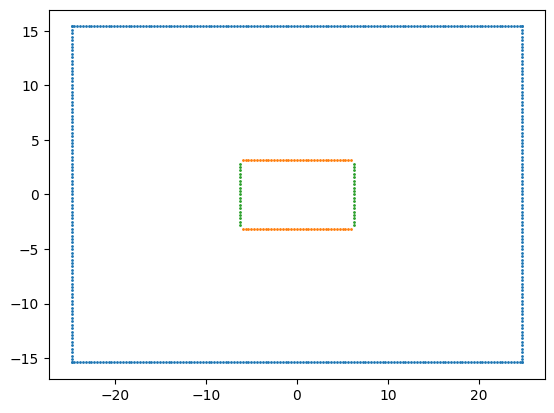

loss1 is  0.00907, loss2 is  0.00000, loss3 is  0.00862, loss4 is  0.00000, loss5 is  1.28504, loss6 is  0.00074, total loss  1.30347, RI value  1.44594:   0%|          | 0/10001 [00:01<?, ?it/s]

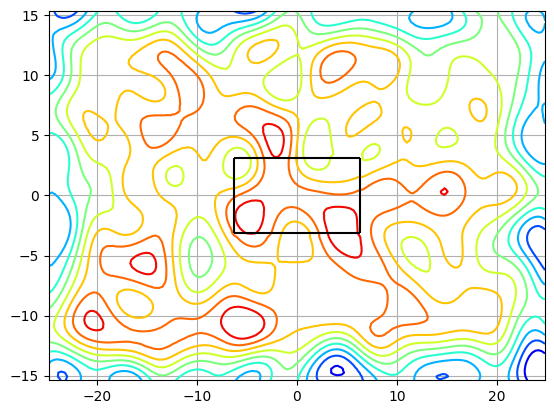

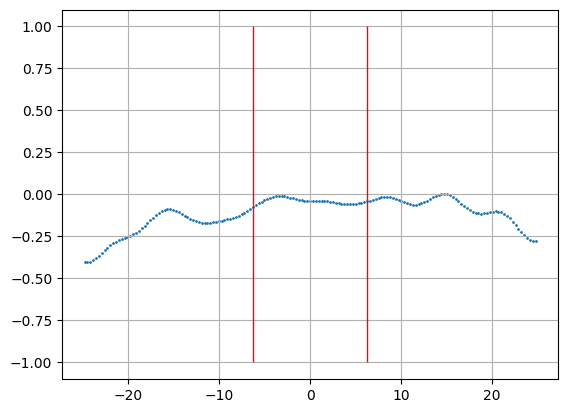

loss1 is  0.00015, loss2 is  0.00009, loss3 is  0.00009, loss4 is  0.00000, loss5 is  0.00006, loss6 is  0.00003, total loss  0.00042, RI value  1.50649:   5%|▍         | 498/10001 [00:19<06:49, 23.22it/s]

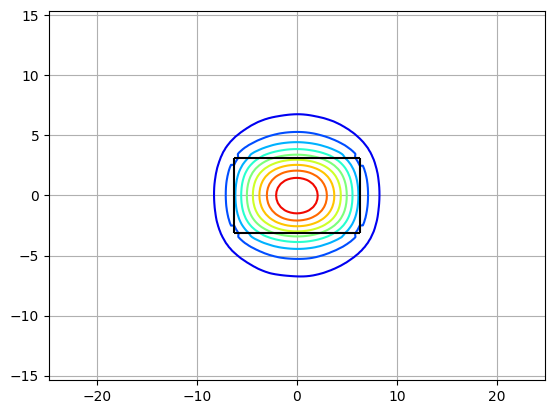

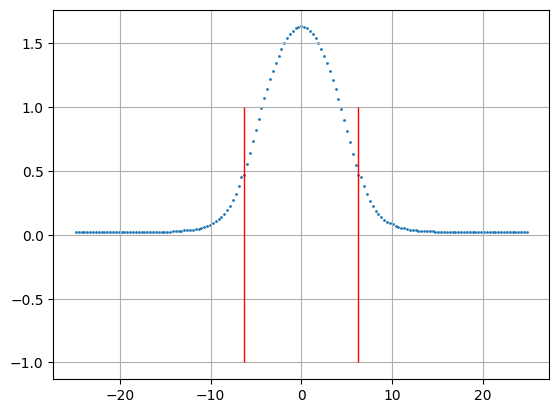

loss1 is  0.00010, loss2 is  0.00007, loss3 is  0.00006, loss4 is  0.00000, loss5 is  0.00000, loss6 is  0.00003, total loss  0.00027, RI value  1.50595:  10%|▉         | 999/10001 [00:39<05:30, 27.24it/s]

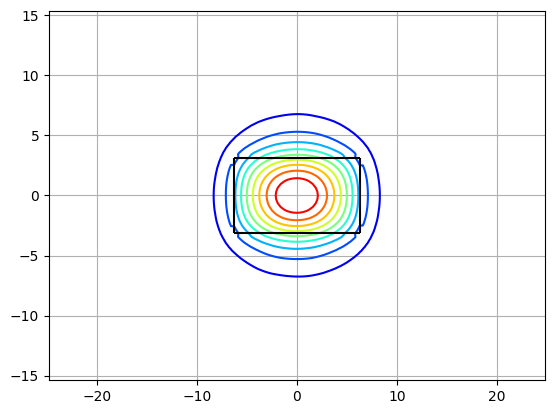

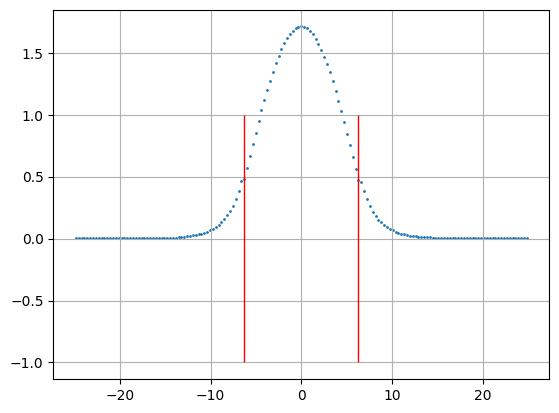

loss1 is  0.00007, loss2 is  0.00005, loss3 is  0.00005, loss4 is  0.00000, loss5 is  0.00006, loss6 is  0.00003, total loss  0.00026, RI value  1.50523:  15%|█▍        | 1498/10001 [01:01<05:07, 27.65it/s]

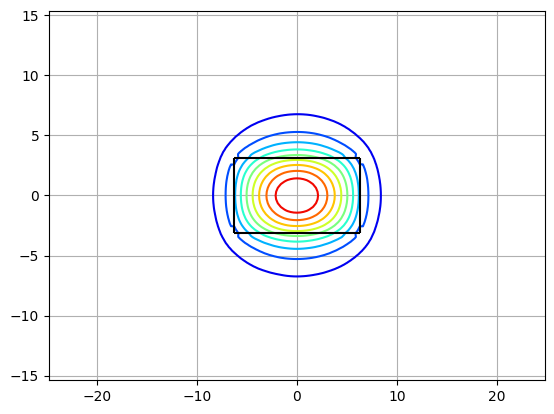

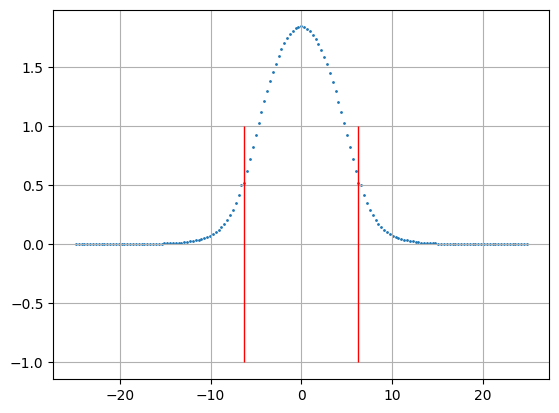

loss1 is  0.00005, loss2 is  0.00003, loss3 is  0.00003, loss4 is  0.00000, loss5 is  0.00008, loss6 is  0.00003, total loss  0.00023, RI value  1.50495:  20%|█▉        | 1999/10001 [01:21<05:38, 23.62it/s]

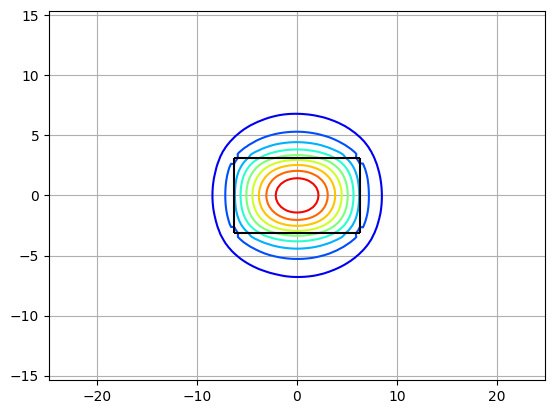

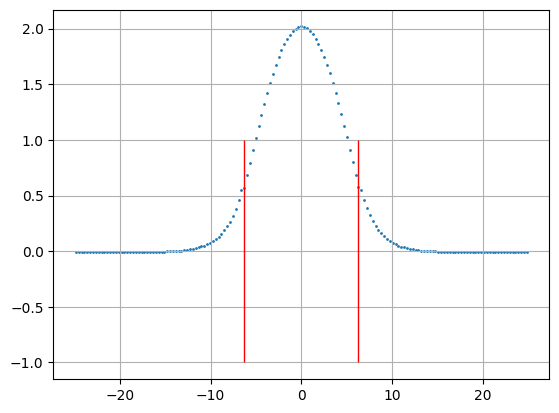

loss1 is  0.00004, loss2 is  0.00003, loss3 is  0.00003, loss4 is  0.00000, loss5 is  0.00021, loss6 is  0.00003, total loss  0.00034, RI value  1.50473:  25%|██▍       | 2498/10001 [01:40<04:24, 28.35it/s]

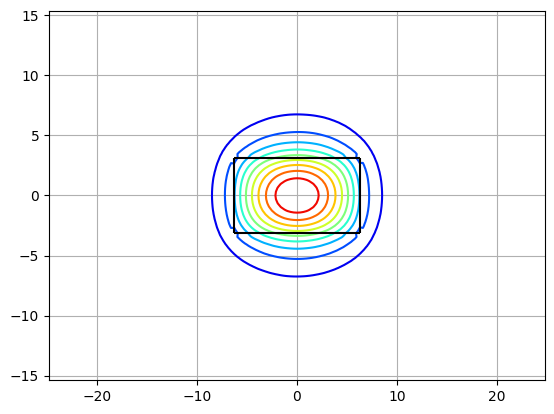

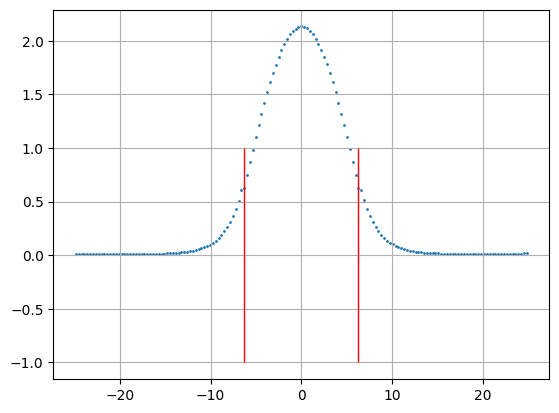

loss1 is  0.00003, loss2 is  0.00002, loss3 is  0.00002, loss4 is  0.00000, loss5 is  0.00000, loss6 is  0.00003, total loss  0.00010, RI value  1.50481:  30%|██▉       | 2997/10001 [02:00<04:15, 27.46it/s]

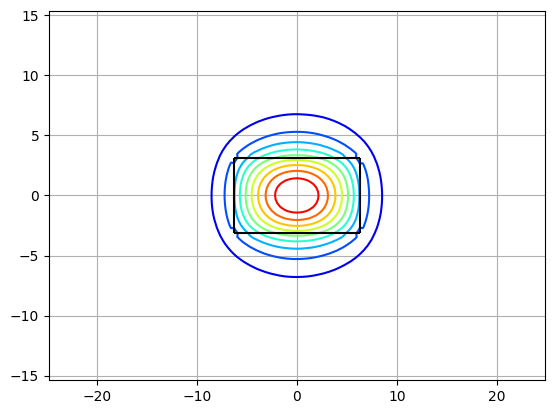

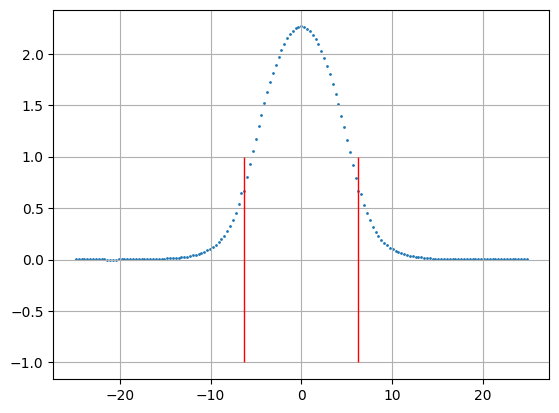

loss1 is  0.00002, loss2 is  0.00002, loss3 is  0.00001, loss4 is  0.00000, loss5 is  0.00001, loss6 is  0.00003, total loss  0.00010, RI value  1.50473:  35%|███▍      | 3498/10001 [02:22<04:35, 23.63it/s]

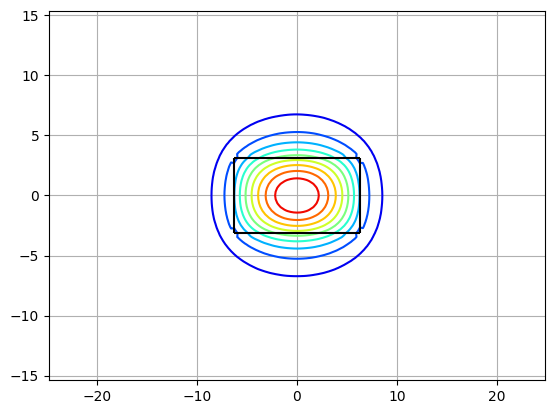

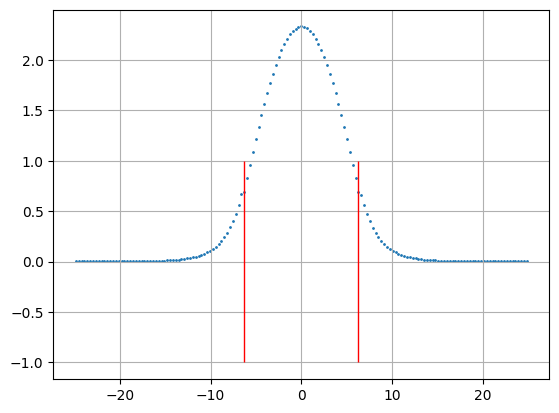

loss1 is  0.00002, loss2 is  0.00002, loss3 is  0.00001, loss4 is  0.00000, loss5 is  0.00000, loss6 is  0.00003, total loss  0.00008, RI value  1.50480:  40%|███▉      | 3999/10001 [02:43<03:42, 26.98it/s]

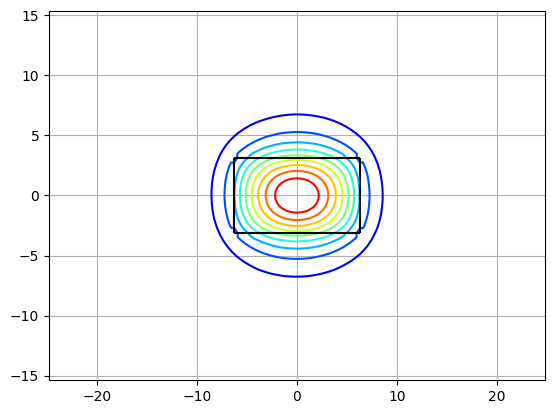

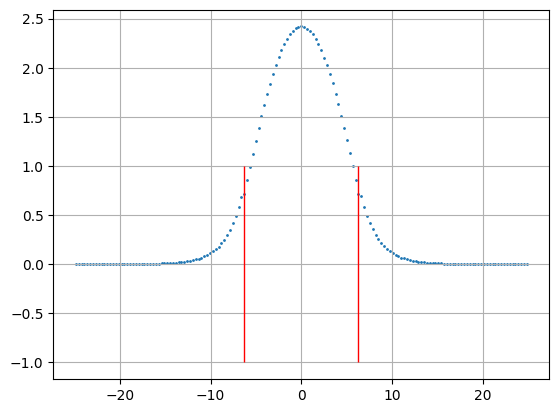

loss1 is  0.00002, loss2 is  0.00002, loss3 is  0.00001, loss4 is  0.00000, loss5 is  0.00000, loss6 is  0.00003, total loss  0.00008, RI value  1.50464:  45%|████▍     | 4500/10001 [03:03<03:47, 24.21it/s]

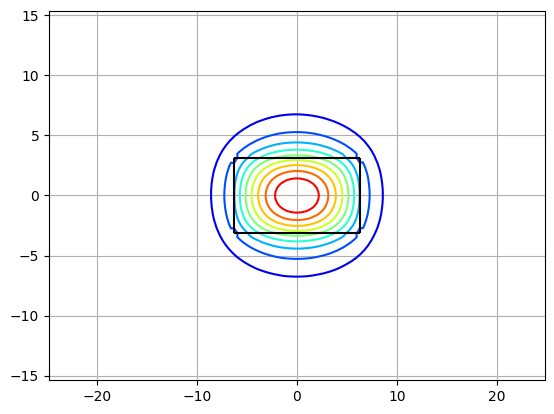

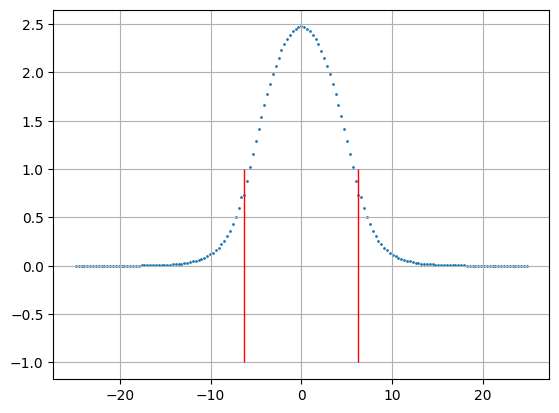

loss1 is  0.00002, loss2 is  0.00001, loss3 is  0.00001, loss4 is  0.00000, loss5 is  0.00000, loss6 is  0.00003, total loss  0.00008, RI value  1.50472:  50%|████▉     | 4998/10001 [03:24<03:19, 25.14it/s]

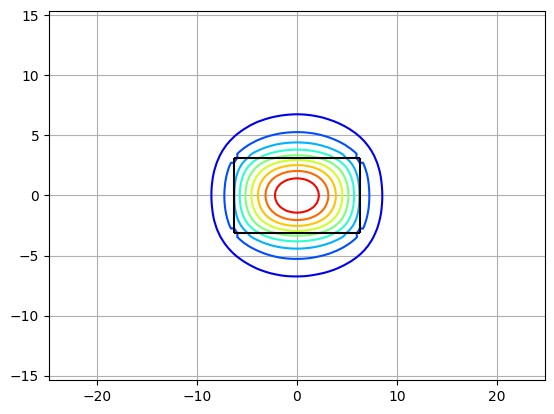

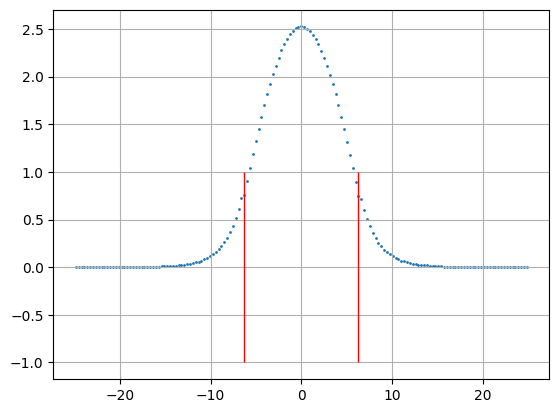

loss1 is  0.00001, loss2 is  0.00001, loss3 is  0.00001, loss4 is  0.00000, loss5 is  0.00000, loss6 is  0.00003, total loss  0.00007, RI value  1.50475:  55%|█████▍    | 5500/10001 [03:45<02:55, 25.70it/s]

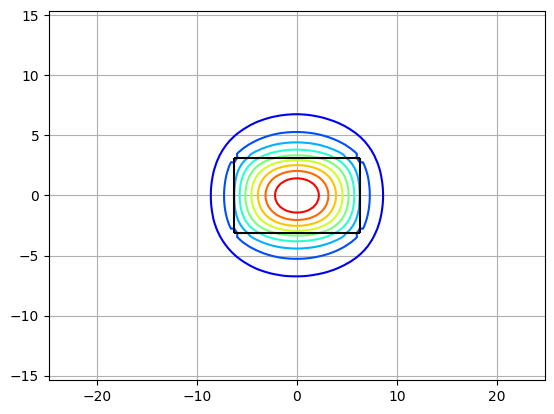

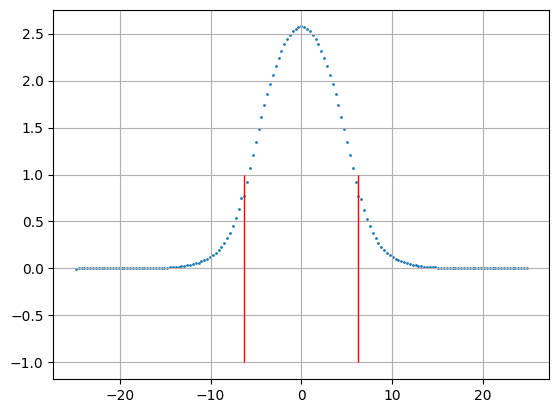

loss1 is  0.00002, loss2 is  0.00001, loss3 is  0.00001, loss4 is  0.00000, loss5 is  0.00000, loss6 is  0.00003, total loss  0.00007, RI value  1.50469:  60%|█████▉    | 5999/10001 [04:06<02:33, 26.02it/s]

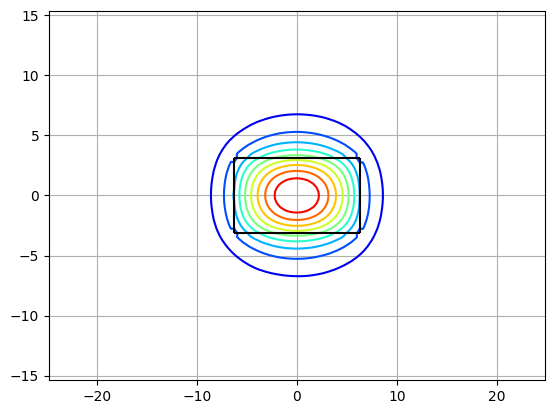

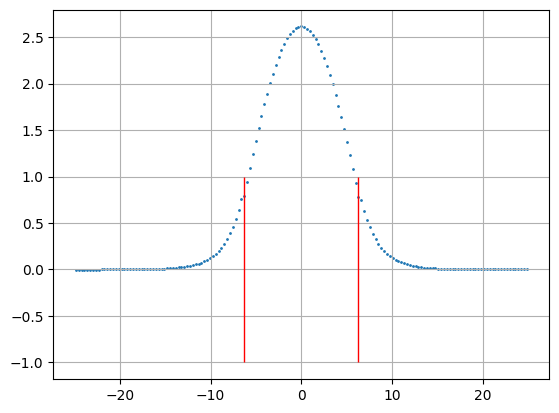

loss1 is  0.00001, loss2 is  0.00001, loss3 is  0.00001, loss4 is  0.00000, loss5 is  0.00000, loss6 is  0.00003, total loss  0.00006, RI value  1.50474:  65%|██████▍   | 6500/10001 [04:26<02:28, 23.63it/s]

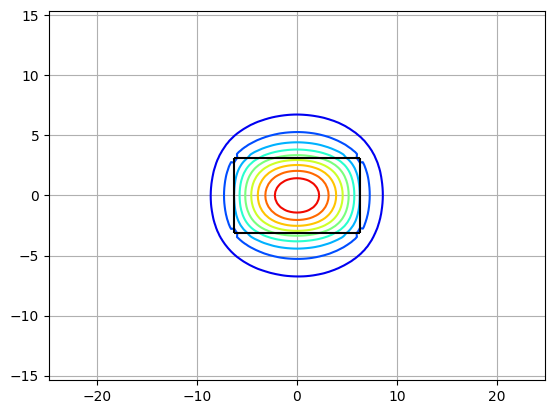

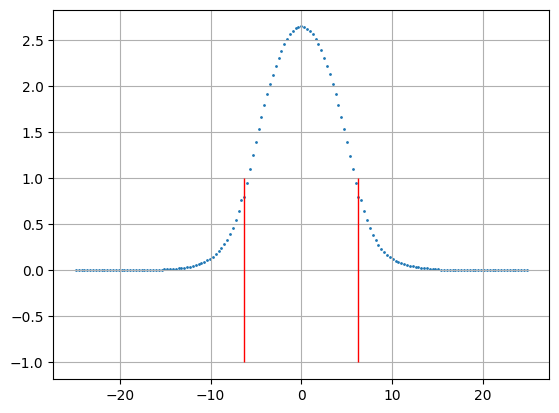

loss1 is  0.00002, loss2 is  0.00001, loss3 is  0.00001, loss4 is  0.00000, loss5 is  0.00004, loss6 is  0.00003, total loss  0.00011, RI value  1.50465:  70%|██████▉   | 6998/10001 [04:44<01:56, 25.75it/s]

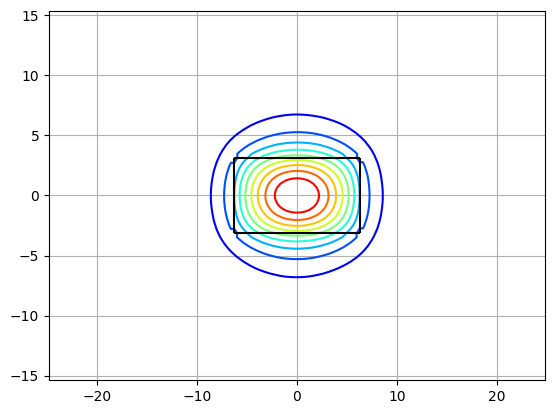

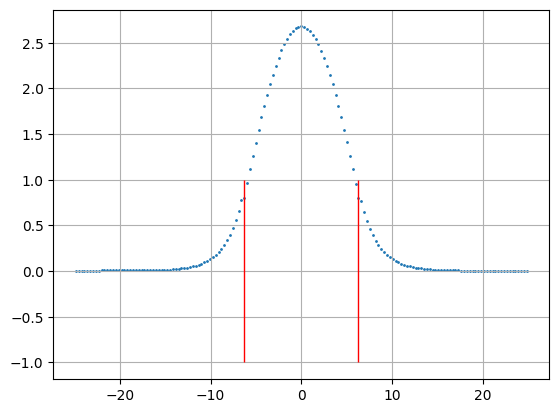

loss1 is  0.00002, loss2 is  0.00001, loss3 is  0.00001, loss4 is  0.00000, loss5 is  0.00000, loss6 is  0.00003, total loss  0.00007, RI value  1.50468:  75%|███████▍  | 7498/10001 [05:05<01:34, 26.45it/s]

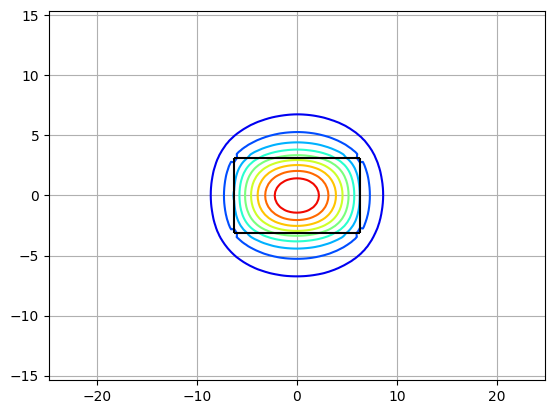

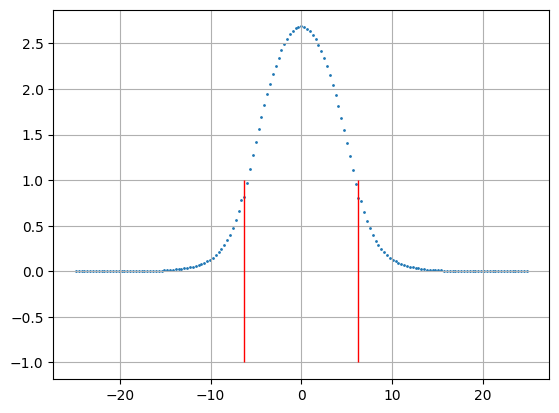

loss1 is  0.00001, loss2 is  0.00001, loss3 is  0.00001, loss4 is  0.00000, loss5 is  0.00000, loss6 is  0.00003, total loss  0.00006, RI value  1.50467:  80%|███████▉  | 7998/10001 [05:24<01:11, 28.00it/s]

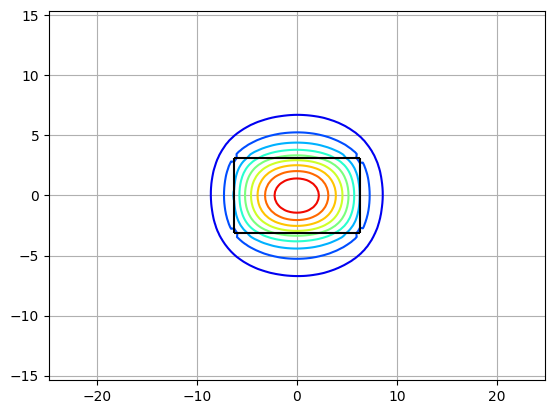

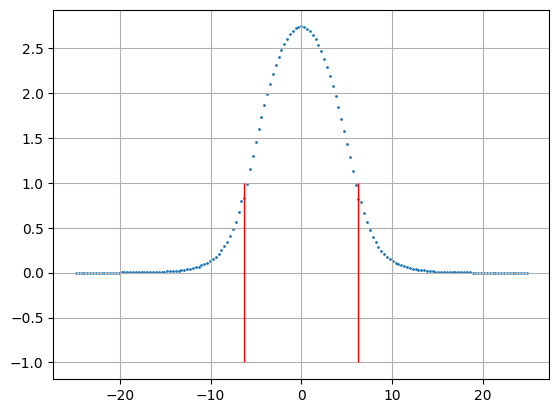

loss1 is  0.00001, loss2 is  0.00001, loss3 is  0.00001, loss4 is  0.00000, loss5 is  0.00000, loss6 is  0.00003, total loss  0.00006, RI value  1.50472:  85%|████████▍ | 8499/10001 [05:44<01:06, 22.72it/s]

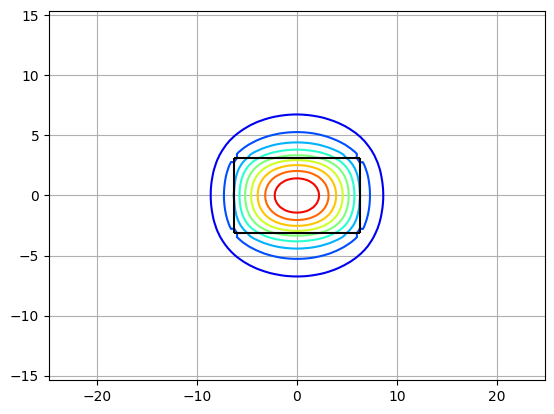

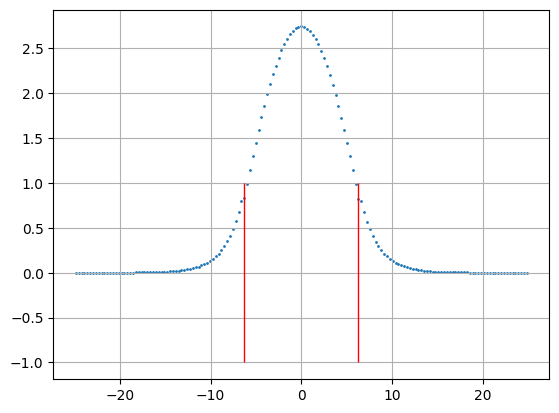

loss1 is  0.00001, loss2 is  0.00001, loss3 is  0.00001, loss4 is  0.00000, loss5 is  0.00000, loss6 is  0.00003, total loss  0.00006, RI value  1.50467:  90%|████████▉ | 9000/10001 [06:04<00:39, 25.24it/s]

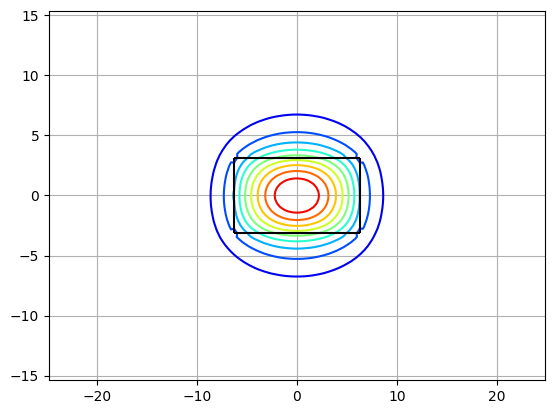

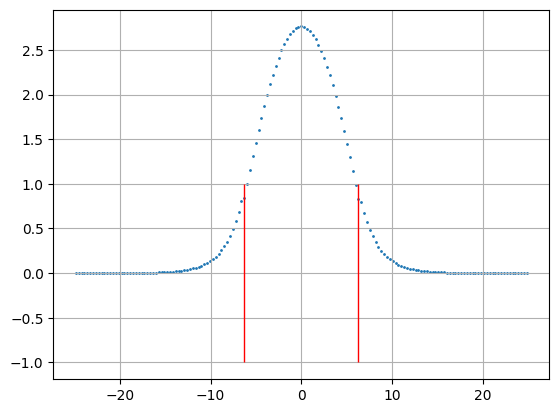

loss1 is  0.00001, loss2 is  0.00001, loss3 is  0.00001, loss4 is  0.00000, loss5 is  0.00000, loss6 is  0.00003, total loss  0.00006, RI value  1.50469:  95%|█████████▍| 9498/10001 [06:23<00:18, 27.17it/s]

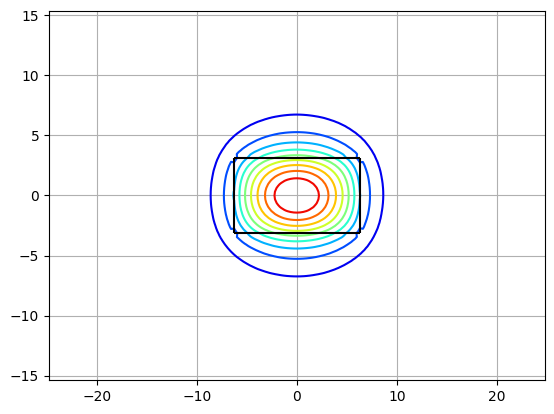

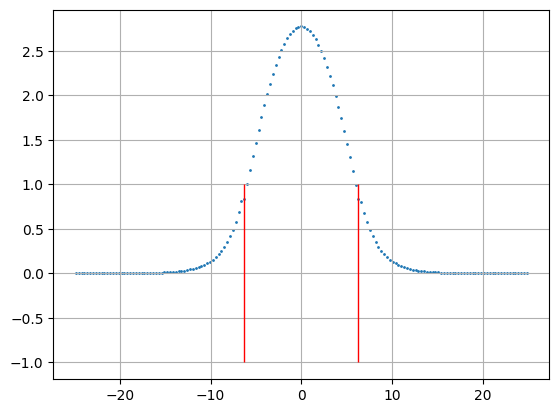

loss1 is  0.00002, loss2 is  0.00001, loss3 is  0.00001, loss4 is  0.00000, loss5 is  0.00000, loss6 is  0.00003, total loss  0.00007, RI value  1.50465: 100%|█████████▉| 9999/10001 [06:44<00:00, 25.65it/s]

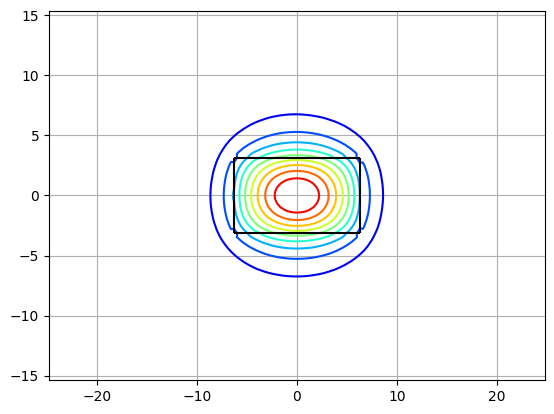

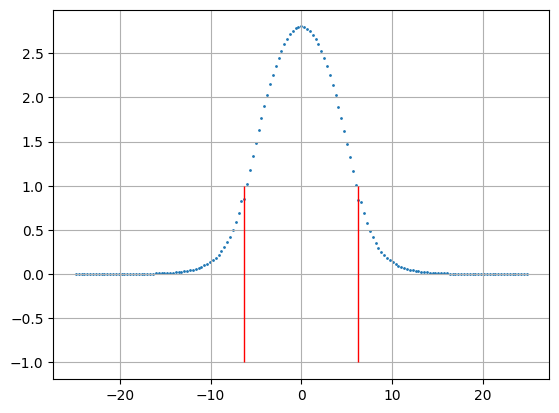

loss1 is  0.00002, loss2 is  0.00001, loss3 is  0.00001, loss4 is  0.00000, loss5 is  0.00000, loss6 is  0.00003, total loss  0.00007, RI value  1.50465: 100%|██████████| 10001/10001 [06:45<00:00, 24.69it/s]


In [123]:
loss_history, rayleigh_history, mode_errors_list = train_agent.train(10001, num_modes, weights=weights, m=m, verbose=10, calc_error=False, plot_solution=True, sample_new=False)

In [124]:
base_model.to('cpu');
base_model.to(torch.float64)

Sequential(
  (0): Linear(in_features=3, out_features=128, bias=True)
  (1): Siren()
  (2): Linear(in_features=128, out_features=128, bias=True)
  (3): Siren()
  (4): Linear(in_features=128, out_features=1, bias=True)
)

In [125]:
# yu = torch.arange(0, reference_device.upward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
# end_val_yu = yu[-1]
# yb = torch.arange(0, reference_device.downward_length, dy, dtype=dtype, device=memory_type).reshape(-1, 1)
# end_val_yb = yb[-1]
# xy = torch.cat((torch.flip(-yb, dims=(0,))[:-1], yu))
# 
# xy = torch.cat((torch.full_like(xy, 0), xy), dim=-1)
# # if device.augmented_input:
# #   xy = torch.cat((xy, (1/reference_device.regions(xy, format='torch').view(-1, 1))), dim=-1)
# u = base_model.forward_with_features(xy.cpu()).cpu()

In [126]:
# plt.scatter(xy[:, 1].cpu().detach(), u[:, 0].detach().numpy(), s=1)
# plt.grid()

In [127]:
xy = torch.arange(0, device.total_length_x/2, dx, dtype=torch.float64).reshape(-1, 1)
xy = torch.cat((-torch.flip(xy, dims=(0,))[:-1], xy))

xy = torch.cat((xy, torch.full_like(xy, 0*dx)), dim=-1)
if device.augmented_input:
  xy = torch.cat((xy, (reference_device.make_features(xy).view(-1, 1))), dim=-1)
u = base_model(xy.cpu()).cpu()[:, [0]]
u = u.detach().numpy()/torch.abs(u).max(dim=0, keepdim=True)[0].detach()

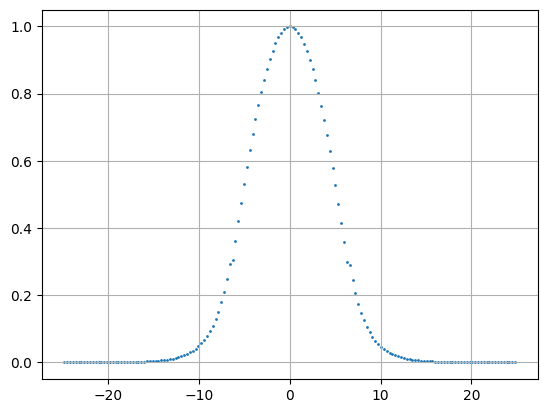

In [128]:
plt.scatter(xy[:, 0].cpu().detach(), u, s=1)
plt.grid()

In [129]:
len(xy[:])

159

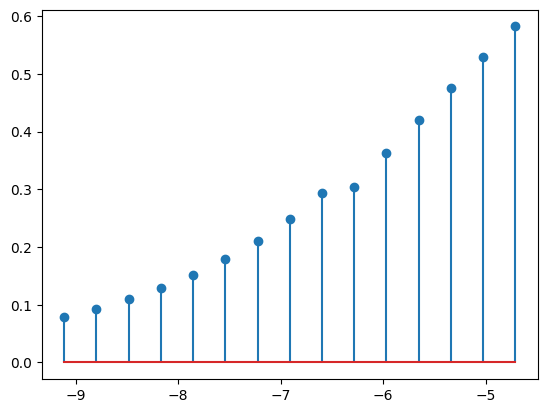

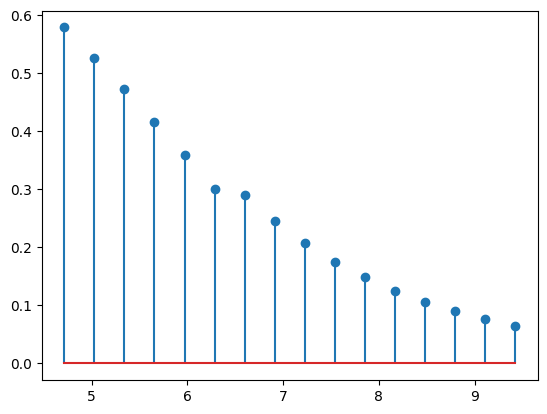

In [130]:
plt.stem(xy[50:65, 0].detach().numpy(), u[50:65, 0].detach().numpy())
plt.show()
plt.stem(xy[95-1:110, 0].detach().numpy(), u[95-1:110, 0].detach().numpy())
plt.show()

In [131]:
reference_device_fd = devices.BuriedChannelWaveguideWithFD(RIs, lambd, lengths_x, lengths_y, study, 'E', dx, dy, num_modes=num_modes)

In [132]:
RI_squared, xy_fd, u_fd = reference_device_fd.evaluate()
xy_fd = torch.from_numpy(xy_fd).to(torch.float64)
xy = torch.cat((xy_fd, device.make_features(xy_fd)), dim=-1)

print(np.sqrt(RI_squared))

[1.50735998]


In [133]:
Nx = int(sum(lengths_x)/(dx)) - 1
Ny = int(sum(lengths_y)/(dy)) - 1
print(len(u_fd), Nx*Ny)

15741 15741


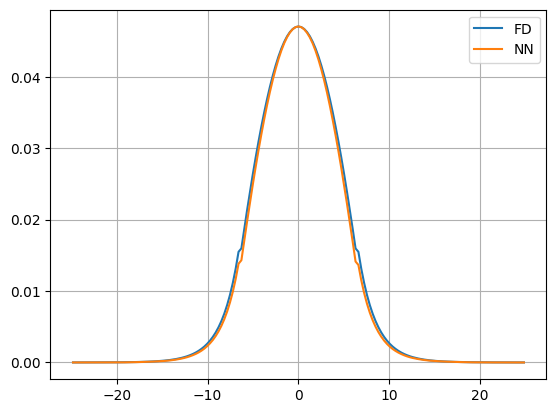

In [134]:
i = int(Ny//2)
row_length = Nx
plt.plot(xy_fd[row_length * i: row_length * (i + 1), 0], -u_fd[row_length * i:row_length * (i + 1), 0], markersize=3, label='FD')
plt.plot(xy_fd[row_length * i: row_length * (i + 1), 0], u*np.max(np.abs(u_fd[row_length * i:row_length * (i + 1), 0])), markersize=3, label='NN')
plt.legend()
plt.grid()

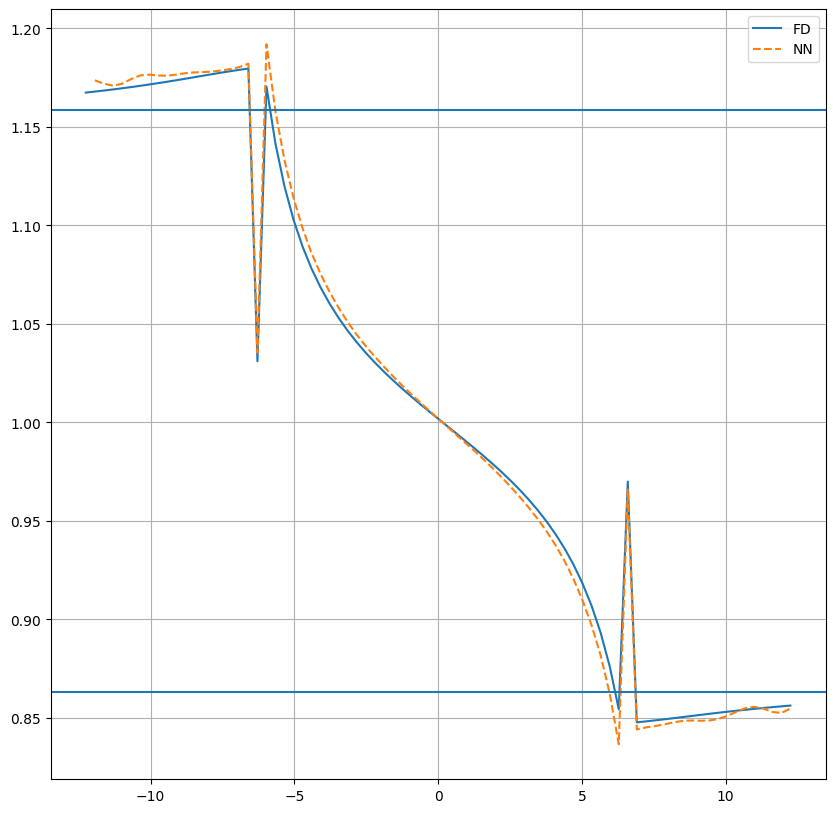

In [135]:
ratio_fd = u_fd[row_length * i:row_length * (i + 1), 0]/u_fd[row_length * i - 1: row_length * (i + 1)-1, 0]
half_index = len(ratio_fd)//2
quarter_index = len(ratio_fd)//4
xy_fd_slice = xy_fd[row_length * i:row_length * (i + 1)][half_index-quarter_index:half_index+quarter_index+1]

u = train_agent.evaluate(xy_fd_slice.cpu())[:, [0]]
u = u.detach().numpy()/torch.abs(u).max(dim=0, keepdim=True)[0].detach()
ratio_nn = u[1:]/u[0:-1]

plt.figure(figsize=(10, 10))
plt.plot(xy_fd_slice[:, 0], ratio_fd[half_index-quarter_index:half_index+quarter_index+1], label='FD')

# plt.stem(xy[50:65, 0].detach().numpy(), -u[50:65, 0].detach().numpy())
# plt.show()
# plt.stem(xy[75-1:90, 0].detach().numpy(), -u[75-1:90, 0].detach().numpy())
# plt.show()
plt.plot(xy_fd_slice[1:, 0], ratio_nn, linestyle='--', label='NN')
plt.axhline(y=(n_core**2)/(n_substrate**2))
plt.axhline(y=(n_substrate**2)/(n_core**2))
# plt.ylim([(n_substrate**2)/(n_core**2)*0.95, (n_core**2)/(n_substrate**2)*1.05])
plt.grid()
plt.legend()

In [136]:
u = base_model(xy.cpu())
u = u/torch.max(torch.abs(u))
u_fd = u_fd/np.max(np.abs(u_fd))

In [137]:
xy.requires_grad = True
NN_EI = [device.calculate_eigen_value(xy.to('cpu'), 0).item()**(1/2)]
print(NN_EI)
xy.requires_grad = False

[1.5047335974215632]


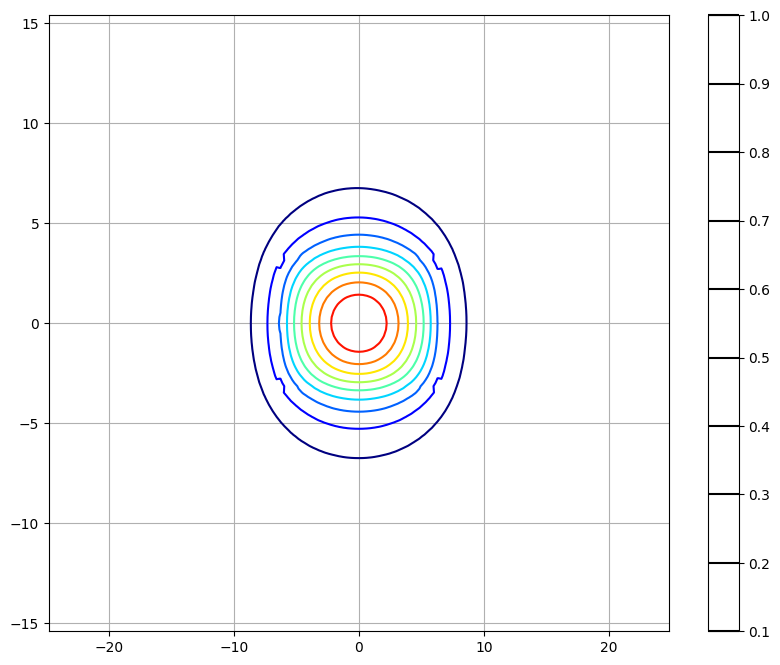

In [138]:
levels = np.linspace(0, np.max(np.abs(u_fd)), 11)[1:]
# levels =  10
plt.figure(figsize=(10, 8))
plt.tricontour(xy[:, 0].cpu().detach(), xy[:, 1].detach().cpu(), u[:,0].detach(), cmap='jet', levels=levels)

plt.tricontour(xy_fd[:, 0], xy_fd[:, 1], u_fd[:,0], linestyles='dashed', levels=levels, colors='black')
plt.colorbar()
plt.grid()

In [32]:
print(len(u))

22101


In [714]:
save_folder_path = r"C:\Users\asmaa\Desktop\Amr\2nd Paper\Experiments"

In [724]:
# np.save(save_folder_path + r'\NonPlanar\Single Mode Weakly Guiding\DCNN_field.npy', u.detach().numpy())
# torch.save(base_model.state_dict(), save_folder_path + r'\NonPlanar\Single Mode Weakly Guiding\DCNN.pty')
# np.save(save_folder_path + r'\NonPlanar\Single Mode Weakly Guiding\NN_EI.npy', NN_EI)
# 
# 
# np.save(save_folder_path + r'\NonPlanar\Single Mode Weakly Guiding\FD_field.npy', u_fd)
# np.save(save_folder_path + r'\NonPlanar\Single Mode Weakly Guiding\FD_EI.npy', [RI_squared])